In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def weekday_word(weekday):
    if weekday==0:
        return "Monday"
    elif weekday==1:
        return "Tuesday"
    elif weekday==2:
        return "Wednesday"
    elif weekday==3:
        return "Thursday"
    elif weekday==4:
        return "Friday"
    elif weekday==5:
        return "Saturday"
    else:
        return "Sunday"
    
def is_weekend(weekday):
    return weekday in [5,6]

### Feature forklaring
- User Type: 
    - Customer = 24-hour pass or 3-day pass
    - Subscriber = Annual Member
- Gender:
    - 0 -> Unknown
    - 1 -> Male
    - 2 -> Female

In [3]:
f=pd.read_csv(r"/Users/katrinepedersen/Desktop/Trips_2018.csv")

In [4]:
f.describe()

,Unnamed: 0,tripduration,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,birth_year,gender
count,1.754834e+07,1.754834e+07,1.754584e+07,1.754834e+07,1.754834e+07,1.754584e+07,1.754834e+07,1.754834e+07,1.754834e+07,1.754834e+07,1.754834e+07
mean,8.774169e+06,9.887432e+02,1.589282e+03,4.073737e+01,-7.398260e+01,1.580830e+03,4.073704e+01,-7.398281e+01,2.656141e+04,1.978993e+03,1.148613e+00
std,5.065769e+06,1.889584e+04,1.439432e+03,3.225813e-02,1.912753e-02,1.438502e+03,3.206583e-02,1.919611e-02,6.222916e+03,1.192922e+01,5.438043e-01
min,0.000000e+00,6.100000e+01,7.200000e+01,4.064654e+01,-7.402535e+01,7.200000e+01,4.064654e+01,-7.408364e+01,1.452900e+04,1.885000e+03,0.000000e+00
25%,4.387084e+06,3.580000e+02,3.800000e+02,4.071755e+01,-7.399521e+01,3.800000e+02,4.071755e+01,-7.399595e+01,2.029300e+04,1.969000e+03,1.000000e+00
50%,8.774169e+06,6.050000e+02,5.050000e+02,4.073818e+01,-7.398565e+01,5.050000e+02,4.073756e+01,-7.398602e+01,2.827000e+04,1.981000e+03,1.000000e+00
75%,1.316125e+07,1.060000e+03,3.249000e+03,4.075763e+01,-7.397283e+01,3.249000e+03,4.075725e+01,-7.397344e+01,3.185200e+04,1.989000e+03,1.000000e+00
max,1.754834e+07,1.951005e+07,3.721000e+03,4.550636e+01,-7.356891e+01,3.721000e+03,4.550636e+01,-7.356891e+01,3.583100e+04,2.002000e+03,2.000000e+00


In [5]:
f = f.rename({"Unnamed: 0": "Trip ID"}, axis="columns")
f = f.set_index("Trip ID")

In [6]:
f.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender
Trip ID,,,,,,,,,,,,,
0,970,2018-01-01 13:50:57.4340,2018-01-01 14:07:08.1860,72.0,40.767272,-73.993929,505.0,40.749013,-73.988484,31956,Subscriber,1992,1
1,723,2018-01-01 15:33:30.1820,2018-01-01 15:45:33.3410,72.0,40.767272,-73.993929,3255.0,40.750585,-73.994685,32536,Subscriber,1969,1
2,496,2018-01-01 15:39:18.3370,2018-01-01 15:47:35.1720,72.0,40.767272,-73.993929,525.0,40.755942,-74.002116,16069,Subscriber,1956,1
3,306,2018-01-01 15:40:13.3720,2018-01-01 15:45:20.1910,72.0,40.767272,-73.993929,447.0,40.763707,-73.985162,31781,Subscriber,1974,1
4,306,2018-01-01 18:14:51.5680,2018-01-01 18:19:57.6420,72.0,40.767272,-73.993929,3356.0,40.774667,-73.984706,30319,Subscriber,1992,1


In [7]:
f['starttime'] = pd.to_datetime(f['starttime'], format='%Y-%m-%d %H:%M:%S.%f')
f['stoptime'] = pd.to_datetime(f['stoptime'], format='%Y-%m-%d %H:%M:%S.%f')
f['weekday']= f['starttime'].dt.weekday
f['is_weekend']=[is_weekend(el) for el in f['weekday']]
# sm_dummies=pd.get_dummies(f, columns=['usertype'])
# sm_dummies.head()

In [8]:
f.dtypes

tripduration                        int64
starttime                  datetime64[ns]
stoptime                   datetime64[ns]
start_station_id                  float64
start_station_latitude            float64
start_station_longitude           float64
end_station_id                    float64
end_station_latitude              float64
end_station_longitude             float64
bikeid                              int64
usertype                           object
birth_year                          int64
gender                              int64
weekday                             int32
is_weekend                           bool
dtype: object

In [9]:
# sm_dummies.dtypes

# Looking at coordinates

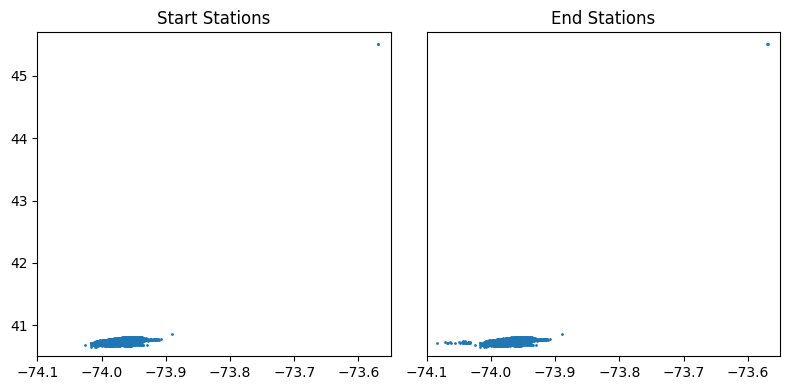

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.55), (40.5, 45.7)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

# Remove outlier

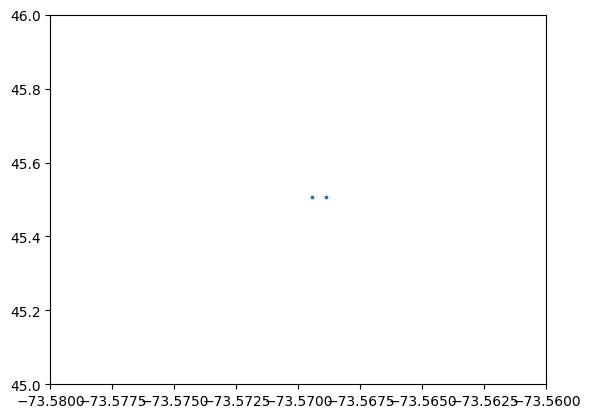

In [11]:
plt.scatter(start_station_df['longitude'], start_station_df['latitude'], s=3)
plt.xlim((-73.58, -73.56))
plt.ylim((45, 46))
plt.show()

In [12]:
start_station_df[start_station_df.longitude > -73.6]

,latitude,longitude
start_station_id,,
3488.0,45.506364,-73.569463
3650.0,45.506264,-73.568906


In [13]:
end_station_df[end_station_df.longitude > -73.6]

,latitude,longitude
end_station_id,,
3488.0,45.506364,-73.569463
3650.0,45.506264,-73.568906


In [14]:
f[
    (f.start_station_id == 3488.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [15]:
f[
    (f.end_station_id == 3488.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,
8772457,1634200,2018-07-18 18:27:51.511,2018-08-06 16:24:32.388,3036.0,40.662908,-73.999722,3488.0,45.506364,-73.569463,24354,Subscriber,1988,1,2,False


In [16]:
f[
    (f.start_station_id == 3650.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [17]:
f[
    (f.end_station_id == 3650.0) &
    (f.start_station_id != f.end_station_id)
]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [18]:
f[
    (f.start_station_id == 3488) | (f.end_station_id == 3488) |
    (f.start_station_id == 3650) | (f.end_station_id == 3650)
].describe()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,birth_year,gender,weekday
count,8.200000e+01,82,82,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,2.954804e+04,2018-03-14 21:46:53.854036736,2018-03-15 05:59:22.416878080,3636.585366,45.447203,-73.574180,3642.097561,45.506269,-73.568933,23651.158537,1985.792683,1.012195,1.378049
min,6.200000e+01,2018-01-08 16:03:59.375000,2018-01-08 16:09:41.338000,3036.000000,40.662908,-73.999722,3488.000000,45.506264,-73.569463,17667.000000,1969.000000,0.000000,0.000000
25%,2.235000e+02,2018-01-26 10:59:14.185999872,2018-01-26 12:46:01.522750208,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,21928.000000,1986.000000,1.000000,0.000000
50%,9.390000e+02,2018-02-20 14:11:07.361499904,2018-02-20 14:12:41.880000,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,24354.000000,1986.000000,1.000000,1.000000
75%,2.653500e+03,2018-05-08 17:10:19.270750208,2018-05-08 17:19:55.421250048,3650.000000,45.506264,-73.568906,3650.000000,45.506264,-73.568906,24354.000000,1986.000000,1.000000,3.000000
max,1.634200e+06,2018-07-18 18:27:51.511000,2018-08-06 16:24:32.388000,3650.000000,45.506364,-73.568906,3650.000000,45.506364,-73.568906,24354.000000,1988.000000,2.000000,4.000000
std,1.827257e+05,NaN,NaN,73.784128,0.534860,0.047574,35.110974,0.000022,0.000121,1256.116408,2.752049,0.248149,1.329998


We have two outliers stations with id 3448 and 3650. We found that they are both placed right next to one another in Montreal, Canada. From the above cells, it is apparent that all but one trips completed with start or end point in Montreal (station 3488 and 3650) are trips in Montreal only.

There is a single trip from Brooklyn (station 3036) to Montreal (station 3488). It's duration is 18.9 days and out of 17 million trips completed, this one is the only one travelling to Montreal. Therefore we classify stations in Montreal as not relevant and outliers.

In [19]:
f = f.drop(
    f[
        (f.start_station_id == 3488) | (f.end_station_id == 3488) |
        (f.start_station_id == 3650) | (f.end_station_id == 3650)
    ].index
)

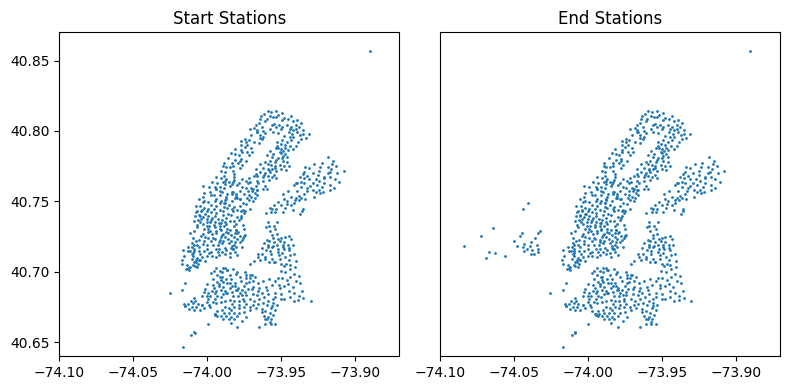

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.87), (40.64, 40.87)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

### Classifying the stations with ID: NaN

We find that a great deal of stations have ID = NaN. So we try and plot them to find their location.

In [21]:
start_ids = np.unique(f.start_station_id)
end_ids = np.unique(f.end_station_id)
print(f"Number of NaN values in start_station_id: {f.start_station_id.isna().sum()}")
print(f"Number of NaN values in end_station_id: {f.end_station_id.isna().sum()}")
start_station_df[start_station_df.index.isna()]

Number of NaN values in start_station_id: 2497
Number of NaN values in end_station_id: 2497


,latitude,longitude
start_station_id,,
NaN,40.857,-73.89


2497 trips have a station ID with NaN-value

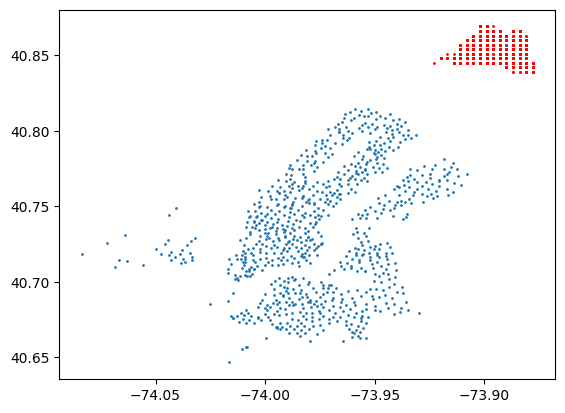

In [22]:
f_nan = f[f.start_station_id.isna()][['start_station_longitude', 'start_station_latitude']]
plt.scatter(f_nan.start_station_longitude, f_nan.start_station_latitude, s=1, c='r', label="NaN-station")
plt.scatter(end_station_df['longitude'], end_station_df['latitude'], s=1)
plt.show()

In [23]:
print("\nCheck: Are the placements different? If all 0, then all placements same")
print(np.unique(f[f.start_station_id.isna()].start_station_longitude) - np.unique(f[f.start_station_id.isna()].end_station_longitude))
print(np.unique(f[f.end_station_id.isna()].start_station_longitude) - np.unique(f[f.end_station_id.isna()].end_station_longitude))
print(np.unique(f[f.start_station_id.isna()].start_station_latitude) - np.unique(f[f.start_station_id.isna()].end_station_latitude))
print(np.unique(f[f.end_station_id.isna()].start_station_latitude) - np.unique(f[f.end_station_id.isna()].end_station_latitude))

print("\nValues for longitude and latitude")
print(np.unique(f[f.start_station_id.isna()].start_station_longitude))
print(np.unique(f[f.start_station_id.isna()].start_station_latitude))

print(f"\nNumber of stations with NaN-value as ID: {len(np.unique(f[f.start_station_id.isna()].start_station_longitude))}")


Check: Are the placements different? If all 0, then all placements same
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Values for longitude and latitude
[-73.923 -73.92  -73.917 -73.914 -73.911 -73.908 -73.905 -73.902 -73.899
 -73.896 -73.893 -73.89  -73.887 -73.884 -73.881 -73.878]
[40.839 40.842 40.845 40.848 40.851 40.854 40.857 40.86  40.863 40.866
 40.869]

Number of stations with NaN-value as ID: 16


Okay, all 16 NaN-ID-stations are located in a single 'cluster' or grouping.
Looking at the placement in a map, the red grouping lies in the Bronx area North of New York. Also as a result of our plotting the single blue dot is the result of dropping duplicates on the ID's. This means that it, in previous plots, represented all the red dots, we now found.

We check whether or not we have data on any trips leaving this grouping. 

In [24]:
f[(f.start_station_id.isna()) & (f.end_station_id.notna())]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


In [25]:
f[(f.start_station_id.notna()) & (f.end_station_id.isna())]

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend
Trip ID,,,,,,,,,,,,,,,


Okay, no trips from a NaN-ID-station leaves the grouping in the Bronx area. Hence, they have no implication on clusters in the central New York area. Since that is the case they wont be important for rebalancing the bike locations, so we classicy them as outliers

In [26]:
f = f.dropna()

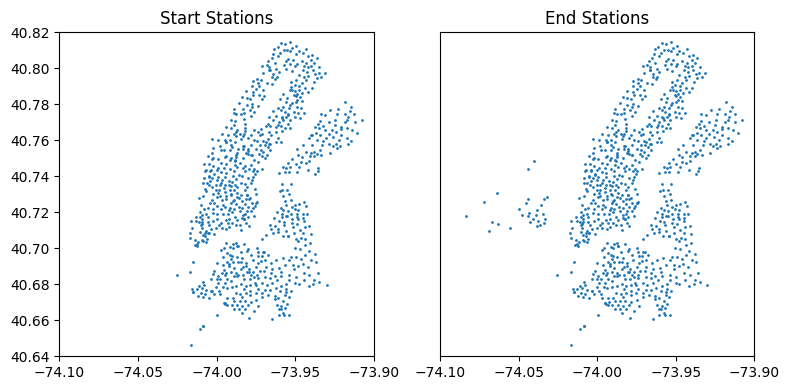

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

xlim, ylim = (-74.1, -73.9), (40.64, 40.82)
dot_size = 1

start_station_df = f.drop_duplicates(subset='start_station_id')[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
start_station_df = start_station_df.set_index("start_station_id")
start_station_df = start_station_df.rename(
    {
        "start_station_latitude": "latitude", 
        "start_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax1.scatter(start_station_df['longitude'],start_station_df['latitude'],s=dot_size)
ax1.set_title("Start Stations")
ax1.set_xlim(*xlim)
ax1.set_ylim(*ylim)

end_station_df = f.drop_duplicates(subset='end_station_id')[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
end_station_df = end_station_df.set_index("end_station_id")
end_station_df = end_station_df.rename(
    {
        "end_station_latitude": "latitude", 
        "end_station_longitude": "longitude"
    }, 
    axis="columns"
)
ax2.scatter(end_station_df['longitude'],end_station_df['latitude'],s=dot_size)
ax2.set_title("End Stations")
ax2.set_xlim(*xlim)
ax2.set_ylim(*ylim)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

## K-means

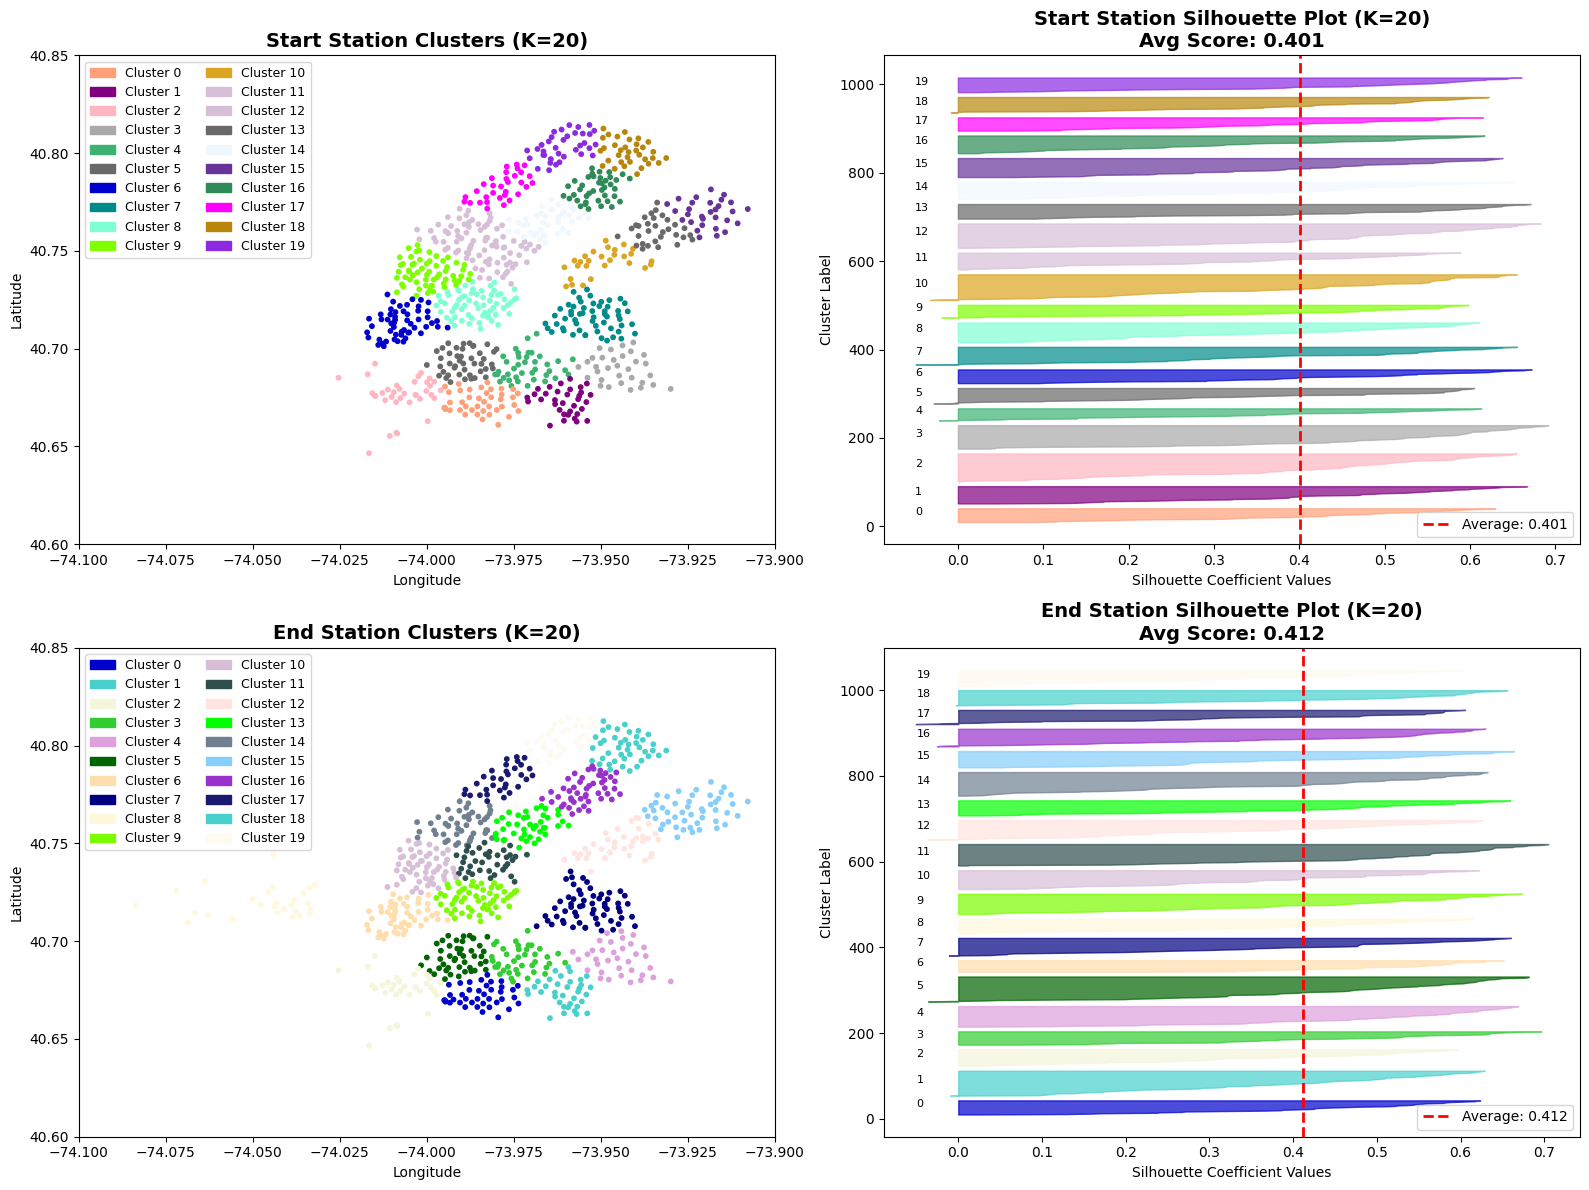

Start Station Average Silhouette Score: 0.401
End Station Average Silhouette Score: 0.412


In [28]:
from sklearn.cluster import KMeans
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import random

K=20

# Fit K-means for start stations
k_start=KMeans(K, random_state=42, n_init=30)
k_end=KMeans(K, random_state=42, n_init=30)

k_start.fit(start_station_df)
k_end.fit(end_station_df)
centroids_start = k_start.cluster_centers_
centroids_end = k_end.cluster_centers_

# Fixing labelling start
order = np.argsort(centroids_start[:, 0])
mapping = {old: new for new, old in enumerate(order)}
fix_labels_start = np.array([mapping[label] for label in k_start.labels_])

# Fixing labelling end
order = np.argsort(centroids_end[:, 0])
mapping = {old: new for new, old in enumerate(order)}
fix_labels_end = np.array([mapping[label] for label in k_end.labels_])

dt_clusters_start=start_station_df.copy()
dt_clusters_start['cluster']= fix_labels_start

dt_clusters_end=end_station_df.copy()
dt_clusters_end['cluster']=fix_labels_end

# Generate colors
num_colors=K
colors=list(mcolors.CSS4_COLORS.keys())
cluster_colors_start = random.choices(colors,k=K)
cluster_colors_end = random.choices(colors,k=K)

# Prepare data for start stations
x_points_start=dt_clusters_start["longitude"]
y_points_start=dt_clusters_start["latitude"]
labels_start = dt_clusters_start["cluster"]
x_start=[]
y_start=[]
c_start=[]
for label, x, y in zip(labels_start, x_points_start, y_points_start):
    if label == -1:
        continue
    x_start.append(x)
    y_start.append(y)
    c_start.append(cluster_colors_start[label])

# Prepare data for end stations
x_points_end=dt_clusters_end["longitude"]
y_points_end=dt_clusters_end["latitude"]
labels_end = dt_clusters_end["cluster"]
x_end=[]
y_end=[]
c_end=[]
for label, x, y in zip(labels_end, x_points_end, y_points_end):
    if label==-1:
        continue
    x_end.append(x)
    y_end.append(y)
    c_end.append(cluster_colors_end[label])

# Calculate silhouette scores
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

silhouette_avg_start = silhouette_score(start_station_df, k_start.labels_)
sample_silhouette_values_start = silhouette_samples(start_station_df, k_start.labels_)

silhouette_avg_end = silhouette_score(end_station_df, k_end.labels_)
sample_silhouette_values_end = silhouette_samples(end_station_df, k_end.labels_)

# Create combined plot with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Start Station Clusters
ax1 = axes[0, 0]
ax1.scatter(x_start, y_start, s=10, c=c_start)
ax1.set_xlim(-74.1, -73.9)
ax1.set_ylim(40.6, 40.85)
ax1.set_title(f'Start Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
legend_patches_start = [Patch(color=cluster_colors_start[i], label=f"Cluster {i}") for i in range(K)]
ax1.legend(handles=legend_patches_start, loc='upper left', fontsize=9, ncol=2)

# Plot 2: Start Station Silhouette Plot
ax2 = axes[0, 1]
y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values_start[k_start.labels_ == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors_start[i]
    ax2.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax2.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10
ax2.set_title(f"Start Station Silhouette Plot (K={K})\nAvg Score: {silhouette_avg_start:.3f}", 
              fontsize=14, fontweight='bold')
ax2.set_xlabel("Silhouette Coefficient Values")
ax2.set_ylabel("Cluster Label")
ax2.axvline(x=silhouette_avg_start, color="red", linestyle="--", linewidth=2, 
            label=f"Average: {silhouette_avg_start:.3f}")
ax2.legend()

# Plot 3: End Station Clusters
ax3 = axes[1, 0]
ax3.scatter(x_end, y_end, s=10, c=c_end)
ax3.set_xlim(-74.1, -73.9)
ax3.set_ylim(40.6, 40.85)
ax3.set_title(f'End Station Clusters (K={K})', fontsize=14, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
legend_patches_end = [Patch(color=cluster_colors_end[i], label=f"Cluster {i}") for i in range(K)]
ax3.legend(handles=legend_patches_end, loc='upper left', fontsize=9, ncol=2)

# Plot 4: End Station Silhouette Plot
ax4 = axes[1, 1]
y_lower = 10
for i in range(K):
    ith_cluster_silhouette_values = sample_silhouette_values_end[k_end.labels_ == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cluster_colors_end[i]
    ax4.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax4.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=8)
    y_lower = y_upper + 10
ax4.set_title(f"End Station Silhouette Plot (K={K})\nAvg Score: {silhouette_avg_end:.3f}", 
              fontsize=14, fontweight='bold')
ax4.set_xlabel("Silhouette Coefficient Values")
ax4.set_ylabel("Cluster Label")
ax4.axvline(x=silhouette_avg_end, color="red", linestyle="--", linewidth=2, 
            label=f"Average: {silhouette_avg_end:.3f}")
ax4.legend()

plt.tight_layout()
plt.show()

print(f"Start Station Average Silhouette Score: {silhouette_avg_start:.3f}")
print(f"End Station Average Silhouette Score: {silhouette_avg_end:.3f}")

# Load a fixed labelling from file

In [29]:
# np.savetxt('fix_labels_start.txt', fix_labels_start) # for updating the fixed cluster labelling used

fixed_cluster_labels = np.loadtxt('fix_labels_start.txt')
dt_clusters_all = dt_clusters_start.copy() # All stations are represented in start_station_id column
dt_clusters_all['cluster'] = fixed_cluster_labels

# Connect clusters with the 17 mio data frame

In [30]:
df_merged_start = f.merge(
    dt_clusters_all['cluster'], 
    left_on='start_station_id', 
    right_index=True, 
    how='left'
)

df_merged_end = f.merge(
    dt_clusters_all['cluster'], 
    left_on='end_station_id', 
    right_index=True, 
    how='left'
)

In [31]:
np.unique(dt_clusters_all[dt_clusters_all.cluster == 12].index)

array([  72.,  173.,  267.,  362.,  379.,  422.,  423.,  447.,  448.,
        449.,  450.,  457.,  465.,  468.,  469.,  477.,  478.,  479.,
        480.,  490.,  492.,  493.,  495.,  499.,  500.,  508.,  513.,
        514.,  515.,  523.,  524.,  525.,  529.,  530.,  533., 2021.,
       3236., 3240., 3255., 3443., 3458., 3466., 3635., 3699., 3712.])

# Investigating a cluster

In [32]:
cluster_4_departures = df_merged_start[df_merged_start["cluster"] == 4].copy()
cluster_4_arrivals = df_merged_end[df_merged_end['cluster'] == 4].copy()
cluster_4_departures.size, cluster_4_arrivals.size

(7780032, 7589120)

In [33]:
# Make sure starttime is a datetime
cluster_4_arrivals['stoptime'] = pd.to_datetime(cluster_4_arrivals['stoptime'])

# Extract date and hour
cluster_4_arrivals['date'] = cluster_4_arrivals['stoptime'].dt.date
cluster_4_arrivals['hour'] = cluster_4_arrivals['stoptime'].dt.hour

# Make sure starttime is a datetime
cluster_4_departures['starttime'] = pd.to_datetime(cluster_4_departures['starttime'])

# Extract date and hour
cluster_4_departures['date'] = cluster_4_departures['starttime'].dt.date
cluster_4_departures['hour'] = cluster_4_departures['starttime'].dt.hour




In [34]:
cluster_4_departures.head()

,tripduration,starttime,stoptime,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bikeid,usertype,birth_year,gender,weekday,is_weekend,cluster,date,hour
Trip ID,,,,,,,,,,,,,,,,,,
2866,904,2018-01-01 08:20:14.048,2018-01-01 08:35:18.290,83.0,40.683826,-73.976323,3300.0,40.665147,-73.976376,31085,Subscriber,1973,1,0,False,4.0,2018-01-01,8
2867,162,2018-01-01 14:56:10.536,2018-01-01 14:58:53.280,83.0,40.683826,-73.976323,3414.0,40.680945,-73.975673,33431,Subscriber,1975,2,0,False,4.0,2018-01-01,14
2868,543,2018-01-01 16:29:05.882,2018-01-01 16:38:09.580,83.0,40.683826,-73.976323,3581.0,40.674012,-73.967146,33352,Subscriber,1986,1,0,False,4.0,2018-01-01,16
2869,330,2018-01-01 16:33:07.794,2018-01-01 16:38:38.149,83.0,40.683826,-73.976323,3413.0,40.682755,-73.982586,17048,Subscriber,1949,1,0,False,4.0,2018-01-01,16
2870,476,2018-01-01 17:15:33.336,2018-01-01 17:23:29.574,83.0,40.683826,-73.976323,3242.0,40.691029,-73.991834,29345,Subscriber,1979,1,0,False,4.0,2018-01-01,17


# Further investigation of what variables to keep for our prediction model

We discussed: leaving out starttime, stoptime, and longitude and latitude for both end station and startstation. The spatial because we now just care which cluster we are in, therefore also leave out the stations ID. Starttime is relevant stop time not su much because we try to predict demand. ANd the trip duration will be kept, also weekend, birth year, most common usertype, and most common gender. Bike ID have also been left out as it seems irrelevant to know which bike goes where at this point. 

In [35]:

grouped_departures = (
    cluster_4_departures.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_departures['datetime'] = pd.to_datetime(grouped_departures['date'].astype(str)) + pd.to_timedelta(grouped_departures['hour'], unit='h')
grouped_departures.set_index('datetime', inplace=True)
grouped_departures.drop(columns=['date'], inplace=True)
grouped_departures.drop(columns=['hour'], inplace=True)
grouped_departures

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,2,False,Subscriber,1,216.000000,1976.000000
2018-01-01 01:00:00,3,False,Subscriber,1,955.000000,1981.333333
2018-01-01 02:00:00,4,False,Subscriber,1,448.500000,1981.500000
2018-01-01 03:00:00,1,False,Subscriber,1,303.000000,1989.000000
2018-01-01 04:00:00,1,False,Subscriber,1,227.000000,1969.000000
...,...,...,...,...,...,...
2018-12-31 18:00:00,10,False,Subscriber,1,593.100000,1982.700000
2018-12-31 19:00:00,4,False,Subscriber,1,387.000000,1977.000000
2018-12-31 20:00:00,6,False,Subscriber,1,1176.166667,1982.833333


In [36]:
# Make sure starttime is a datetime
cluster_4_arrivals['stoptime'] = pd.to_datetime(cluster_4_arrivals['stoptime'])

# Extract date and hour
cluster_4_arrivals['date'] = cluster_4_arrivals['stoptime'].dt.date
cluster_4_arrivals['hour'] = cluster_4_arrivals['stoptime'].dt.hour

grouped_arrivals = (
    cluster_4_arrivals.groupby(['date', 'hour'])
      .agg(
          trip_count=('tripduration', 'count'),
          is_weekend=('is_weekend', 'first'),
          most_common_user_type=('usertype', lambda x: x.value_counts().index[0]),
          most_common_gender=('gender', lambda x: x.value_counts().index[0]),
          duration_mean=('tripduration', 'mean'),
          birth_mean=('birth_year', 'mean')
      )
      .reset_index()
)

grouped_arrivals['datetime'] = pd.to_datetime(grouped_arrivals['date'].astype(str)) + pd.to_timedelta(grouped_arrivals['hour'], unit='h')
grouped_arrivals.set_index('datetime', inplace=True)
grouped_arrivals.drop(columns=['date'], inplace=True)
grouped_arrivals.drop(columns=['hour'], inplace=True)
grouped_arrivals

,trip_count,is_weekend,most_common_user_type,most_common_gender,duration_mean,birth_mean
datetime,,,,,,
2018-01-01 00:00:00,4,False,Subscriber,1,4.142500e+02,1982.750000
2018-01-01 01:00:00,5,False,Subscriber,1,1.337000e+03,1981.200000
2018-01-01 02:00:00,6,False,Subscriber,1,7.136667e+02,1976.666667
2018-01-01 03:00:00,5,False,Subscriber,1,1.105000e+03,1986.400000
2018-01-01 04:00:00,5,False,Subscriber,1,3.742000e+02,1977.200000
...,...,...,...,...,...,...
2018-12-31 20:00:00,4,False,Subscriber,1,5.062500e+02,1990.000000
2018-12-31 21:00:00,4,False,Subscriber,1,1.846500e+03,1972.000000
2018-12-31 22:00:00,3,False,Subscriber,1,3.493333e+02,1979.666667


# RandomForestRegressor

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def print_stats(y_test, y_preds, title="You forgot the title!"):
    print(title+": ")
    print("\tr^2=%f"%r2_score(y_test,y_preds))
    print("\tMSE=%f"%mean_squared_error(y_test,y_preds))
    print("\tMAE=%f"%mean_absolute_error(y_test,y_preds))
    print("\tMAPE=%f"%mean_absolute_percentage_error(y_test,y_preds))

def plotprediction(series, pred_series, labels=["original", "predicted"], x_axis=None, plot_intervals=False, scale=1.96, plot_anomalies=False, title="prediction"):

    plt.figure(figsize=(15,5))
    plt.title(title)
    if x_axis is None:
        x_axis=series.index
    
    plt.plot(x_axis, pred_series, "g", label=labels[1])
    plt.plot(x_axis, series, label=labels[0])
    

    # Plot confidence intervals for smoothed values

    plt.legend(loc="upper left")
    plt.grid(True)
    plt.show()

## Creation - Departures

In [38]:
from sklearn.ensemble import RandomForestRegressor

# --- Create lag features for 24, 48, 72 hours ---
for lag in [24, 25, 26, 27, 28, 48, 72, 166, 167, 168, 169, 170, 171]:
    grouped_departures[f'lag_{lag}'] = grouped_departures['trip_count'].shift(lag)

# --- Calendar / time features from the datetime index ---
grouped_departures['hour']  = grouped_departures.index.hour
grouped_departures['dow']   = grouped_departures.index.weekday   # 0=Mon,...,6=Sun
grouped_departures['month'] = grouped_departures.index.month

# One-hot encode categorical variables (user type and gender)
grouped_rf_departures = pd.get_dummies(
    grouped_departures,
    columns=['most_common_user_type', 'most_common_gender'],
    drop_first=True
)

In [39]:

# Drop first rows where lag features are NaN (because of shifting)
grouped_rf_departures = grouped_rf_departures.dropna(subset=['lag_24', 'lag_48', 'lag_72', 'lag_171'])


In [40]:
grouped_rf_departures.head()

,trip_count,is_weekend,duration_mean,birth_mean,lag_24,lag_25,lag_26,lag_27,lag_28,lag_48,...,lag_168,lag_169,lag_170,lag_171,hour,dow,month,most_common_user_type_Subscriber,most_common_gender_1,most_common_gender_2
datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-08 23:00:00,8,False,646.625,1983.875,6.0,6.0,12.0,20.0,12.0,10.0,...,1.0,4.0,3.0,2.0,23,0,1,True,False,True
2018-01-09 00:00:00,4,False,382.500,1971.750,6.0,6.0,6.0,12.0,20.0,6.0,...,1.0,1.0,4.0,3.0,0,1,1,True,False,True
2018-01-09 01:00:00,1,False,361.000,1999.000,1.0,6.0,6.0,6.0,12.0,2.0,...,2.0,1.0,1.0,4.0,1,1,1,True,True,False
2018-01-09 02:00:00,1,False,833.000,1969.000,5.0,1.0,6.0,6.0,6.0,3.0,...,2.0,2.0,1.0,1.0,2,1,1,False,False,False
2018-01-09 04:00:00,1,False,224.000,1969.000,1.0,5.0,1.0,6.0,6.0,3.0,...,1.0,2.0,2.0,1.0,4,1,1,True,True,False


In [41]:
# Use the same temporal split as before
test_start = pd.Timestamp("2018-11-01")
test_end   = pd.Timestamp("2018-12-31")

train_mask_rf = grouped_rf_departures.index < test_start
test_mask_rf  = (grouped_rf_departures.index >= test_start) & (grouped_rf_departures.index <= test_end)

# Define feature columns (exclude target and naive copy column)
feature_cols_departures = [
    c for c in grouped_rf_departures.columns 
    if c not in ['trip_count']  # 'copy_pred' exists from the naive model
]

X_train_departures = grouped_rf_departures.loc[train_mask_rf, feature_cols_departures]
y_train_departures = grouped_rf_departures.loc[train_mask_rf, 'trip_count']

X_test_departures  = grouped_rf_departures.loc[test_mask_rf, feature_cols_departures]
y_test_departures  = grouped_rf_departures.loc[test_mask_rf, 'trip_count']


In [42]:
feature_cols_departures

['is_weekend',
 'duration_mean',
 'birth_mean',
 'lag_24',
 'lag_25',
 'lag_26',
 'lag_27',
 'lag_28',
 'lag_48',
 'lag_72',
 'lag_166',
 'lag_167',
 'lag_168',
 'lag_169',
 'lag_170',
 'lag_171',
 'hour',
 'dow',
 'month',
 'most_common_user_type_Subscriber',
 'most_common_gender_1',
 'most_common_gender_2']

In [43]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_departures, y_train_departures)

y_pred_rf_departures = rf.predict(X_test_departures)

print("===TRAINING SET STATS===")
print_stats(y_train_departures, rf.predict(X_train_departures), "Random Forest (lags 24/48/72) – departures, cluster 12")
print("===TEST SET STATS===")
print_stats(y_test_departures, y_pred_rf_departures, "Random Forest (lags 24/48/72) – departures, cluster 12")


===TRAINING SET STATS===
Random Forest (lags 24/48/72) – departures, cluster 12: 
	r^2=0.970897
	MSE=80.556371
	MAE=5.605370
	MAPE=20.979151
===TEST SET STATS===
Random Forest (lags 24/48/72) – departures, cluster 12: 
	r^2=0.614389
	MSE=681.064603
	MAE=17.943209
	MAPE=108.192762


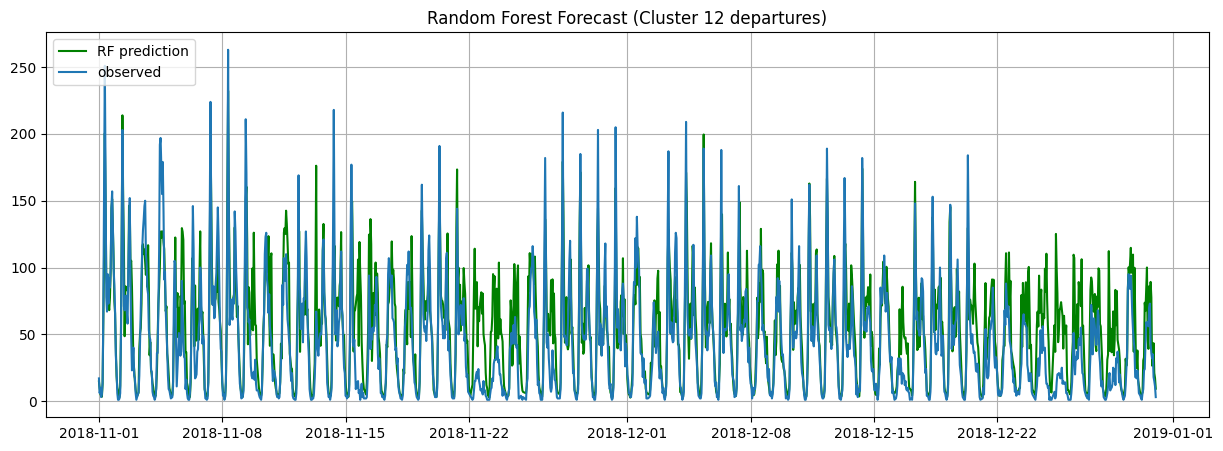

In [44]:
y_pred_rf_departures = pd.Series(rf.predict(X_test_departures), index=X_test_departures.index, name="y_pred_rf")
y_test_departures = pd.Series(y_test_departures, index=X_test_departures.index, name="y_test")

plotprediction(
    series = y_test_departures,
    pred_series = y_pred_rf_departures,
    labels = ['observed', 'RF prediction'],
    title = "Random Forest Forecast (Cluster 12 departures)"
)

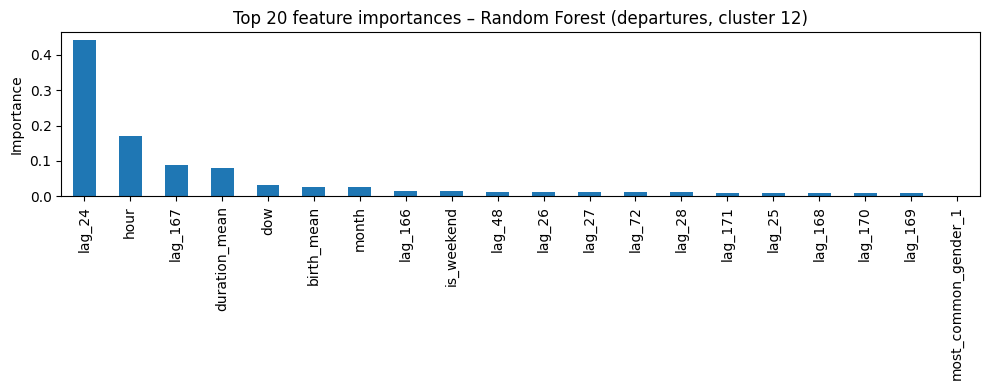

lag_168                 0.009570
lag_24                  0.442021
lag_72                  0.012119
most_common_gender_1    0.000042
dtype: float64


In [45]:
importances = pd.Series(rf.feature_importances_, index=feature_cols_departures)
imp_top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top.plot(kind='bar')
plt.title("Top 20 feature importances – Random Forest (departures, cluster 12)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# If you want to see just the lags:
print(importances[['lag_168', 'lag_24', 'lag_72', 'most_common_gender_1']])


## Creation - Arrivals 

In [46]:
from sklearn.ensemble import RandomForestRegressor

# --- Create lag features for 24, 48, 72 hours ---
for lag in [24, 25, 26, 27, 28, 48, 72, 166, 167, 168, 169, 170, 171]:
    grouped_arrivals[f'lag_{lag}'] = grouped_arrivals['trip_count'].shift(lag)

# --- Calendar / time features from the datetime index ---
grouped_arrivals['hour']  = grouped_arrivals.index.hour
grouped_arrivals['dow']   = grouped_arrivals.index.weekday   # 0=Mon,...,6=Sun
grouped_arrivals['month'] = grouped_arrivals.index.month

# One-hot encode categorical variables (user type and gender)
grouped_rf_arrivals = pd.get_dummies(
    grouped_arrivals,
    columns=['most_common_user_type', 'most_common_gender'],
    drop_first=True
)


# Drop first rows where lag features are NaN (because of shifting)
grouped_rf_arrivals = grouped_rf_arrivals.dropna(subset=['lag_24', 'lag_48', 'lag_72', 'lag_171'])

# Use the same temporal split as before
test_start = pd.Timestamp("2018-11-01")
test_end   = pd.Timestamp("2018-12-31")

train_mask_rf = grouped_rf_arrivals.index < test_start
test_mask_rf  = (grouped_rf_arrivals.index >= test_start) & (grouped_rf_arrivals.index <= test_end)

# Define feature columns (exclude target and naive copy column)
feature_cols_arrivals = [
    c for c in grouped_rf_arrivals.columns 
    if c not in ['trip_count']  # 'copy_pred' exists from the naive model
]

X_train_arrivals = grouped_rf_arrivals.loc[train_mask_rf, feature_cols_arrivals]
y_train_arrivals = grouped_rf_arrivals.loc[train_mask_rf, 'trip_count']

X_test_arrivals  = grouped_rf_arrivals.loc[test_mask_rf, feature_cols_arrivals]
y_test_arrivals  = grouped_rf_arrivals.loc[test_mask_rf, 'trip_count']

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_arrivals, y_train_arrivals)

y_pred_rf_arrivals = rf.predict(X_test_arrivals)

print("===TRAINING SET STATS===")
print_stats(y_train_arrivals, rf.predict(X_train_arrivals), "Random Forest (lags 24/48/72) – arrivals, cluster 12")
print("===TEST SET STATS===")
print_stats(y_test_arrivals, y_pred_rf_arrivals, "Random Forest (lags 24/48/72) – arrivals, cluster 12")

===TRAINING SET STATS===
Random Forest (lags 24/48/72) – arrivals, cluster 12: 
	r^2=0.970295
	MSE=76.593179
	MAE=5.503681
	MAPE=21.642646
===TEST SET STATS===
Random Forest (lags 24/48/72) – arrivals, cluster 12: 
	r^2=0.543727
	MSE=707.917343
	MAE=18.424668
	MAPE=121.409958


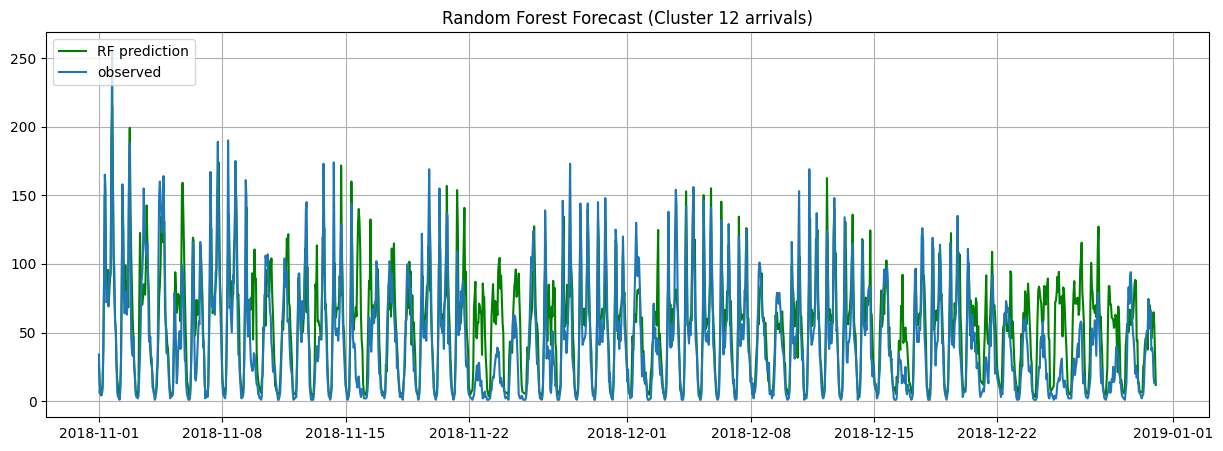

In [47]:
y_pred_rf_arrivals = pd.Series(rf.predict(X_test_arrivals), index=X_test_arrivals.index, name="y_pred_rf")
y_test_arrivals = pd.Series(y_test_arrivals, index=X_test_arrivals.index, name="y_test")

plotprediction(
    series = y_test_arrivals,
    pred_series = y_pred_rf_arrivals,
    labels = ['observed', 'RF prediction'],
    title = "Random Forest Forecast (Cluster 12 arrivals)")

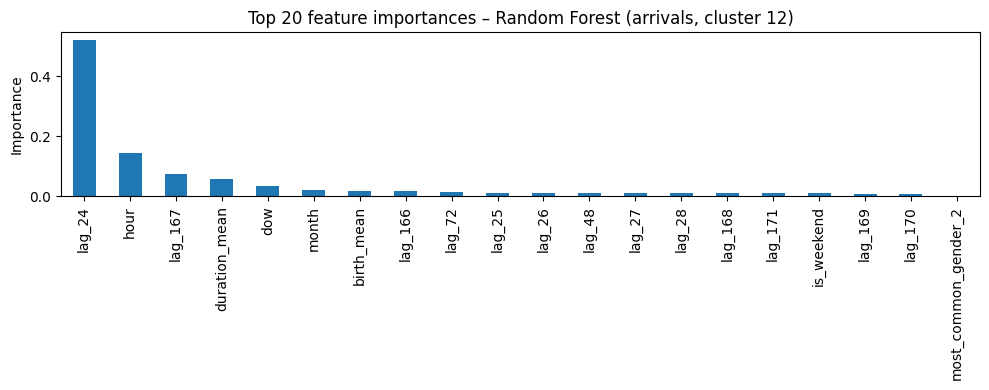

lag_168                 0.009702
lag_24                  0.519623
lag_72                  0.013149
most_common_gender_1    0.000011
dtype: float64


In [48]:
importances = pd.Series(rf.feature_importances_, index=feature_cols_arrivals)
imp_top = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,4))
imp_top.plot(kind='bar')
plt.title("Top 20 feature importances – Random Forest (arrivals, cluster 12)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# If you want to see just the lags:
print(importances[['lag_168', 'lag_24', 'lag_72', 'most_common_gender_1']])

## Bike allocation 

In [49]:
y_pred_rf_arrivals = pd.Series(y_pred_rf_arrivals, index=X_test_arrivals.index)
y_pred_rf_departures = pd.Series(y_pred_rf_departures, index=X_test_departures.index)

rf_bike_alloc_pred = (y_pred_rf_arrivals - y_pred_rf_departures).to_frame(name="diff")

nan_indexes = rf_bike_alloc_pred[rf_bike_alloc_pred.isna().any(axis=1)].index
nan_indexes

DatetimeIndex(['2018-11-03 05:00:00', '2018-11-05 01:00:00',
               '2018-11-06 01:00:00', '2018-11-07 03:00:00',
               '2018-11-08 03:00:00', '2018-11-10 04:00:00',
               '2018-11-15 03:00:00', '2018-11-18 05:00:00',
               '2018-11-20 03:00:00', '2018-11-23 02:00:00',
               '2018-11-23 03:00:00', '2018-11-23 05:00:00',
               '2018-11-24 02:00:00', '2018-11-24 03:00:00',
               '2018-11-24 05:00:00', '2018-11-24 22:00:00',
               '2018-11-25 05:00:00', '2018-11-27 03:00:00',
               '2018-11-27 04:00:00', '2018-12-02 02:00:00',
               '2018-12-02 03:00:00', '2018-12-04 02:00:00',
               '2018-12-07 03:00:00', '2018-12-10 02:00:00',
               '2018-12-10 03:00:00', '2018-12-11 03:00:00',
               '2018-12-15 04:00:00', '2018-12-15 05:00:00',
               '2018-12-16 03:00:00', '2018-12-19 04:00:00',
               '2018-12-20 03:00:00', '2018-12-20 04:00:00',
               '2018-12-

In [50]:
for ts in nan_indexes:
    # If arrivals has a prediction for this timestamp
    if ts in y_pred_rf_arrivals.index:
        rf_bike_alloc_pred.loc[ts] = y_pred_rf_arrivals.loc[ts]
    else:
        # If not, fall back to negative departures
        rf_bike_alloc_pred.loc[ts] = -y_pred_rf_departures.loc[ts]


In [51]:

rf_bike_alloc_pred["daily_cumsum"] = rf_bike_alloc_pred.groupby(rf_bike_alloc_pred.index.date)["diff"].cumsum()
min_daily_cumsum_pred = rf_bike_alloc_pred.groupby(rf_bike_alloc_pred.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min")
)


min_daily_cumsum_pred["bikes_to_allocate"] = (
    min_daily_cumsum_pred["min_daily_cumsum"]
    .apply(lambda x: np.ceil(abs(x)) if x < 0 else 0)
)
min_daily_cumsum_pred

,min_daily_cumsum,bikes_to_allocate
2018-11-01,-133.528518,134.0
2018-11-02,-171.778254,172.0
2018-11-03,-5.893721,6.0
2018-11-04,-128.461032,129.0
2018-11-05,-58.981185,59.0
...,...,...
2018-12-27,-55.191147,56.0
2018-12-28,-22.325014,23.0
2018-12-29,-265.387018,266.0
2018-12-30,-228.730005,229.0


In [52]:
"""
y_test_rf_arrivals = pd.Series(y_test_arrivals, index=X_test_arrivals.index)
y_test_rf_departures = pd.Series(y_test_departures, index=X_test_departures.index)

rf_bike_alloc_test = (y_test_rf_arrivals - y_test_rf_departures).to_frame(name="diff")

nan_indexes = rf_bike_alloc_test[rf_bike_alloc_test.isna().any(axis=1)].index
nan_indexes

for ts in nan_indexes:
    # If arrivals has a prediction for this timestamp
    if ts in y_pred_rf_arrivals.index:
        rf_bike_alloc_pred.loc[ts] = y_pred_rf_arrivals.loc[ts]
    else:
        # If not, fall back to negative departures
        rf_bike_alloc_pred.loc[ts] = -y_pred_rf_departures.loc[ts]

rf_bike_alloc_test["daily_cumsum"] = rf_bike_alloc_test.groupby(rf_bike_alloc_test.index.date)["diff"].cumsum()
min_daily_cumsum_test = rf_bike_alloc_test.groupby(rf_bike_alloc_test.index.date).agg(
    min_daily_cumsum=("daily_cumsum", "min")
)


min_daily_cumsum_test["bikes_to_allocate"] = (
    min_daily_cumsum_test["min_daily_cumsum"]
    .apply(lambda x: np.ceil(abs(x)) if x < 0 else 0)
)
min_daily_cumsum_test
"""

min_daily_cumsum_test = pd.read_json("min_daily_cumsum_test_4.json")
min_daily_cumsum_test


,min_daily_cumsum,bikes_to_allocate
2018-11-01,-187,187
2018-11-02,-122,122
2018-11-03,-85,85
2018-11-04,-146,146
2018-11-05,-94,94
...,...,...
2018-12-27,-80,80
2018-12-28,-26,26
2018-12-29,-81,81
2018-12-30,-50,50


In [53]:
print_stats(min_daily_cumsum_test["bikes_to_allocate"], min_daily_cumsum_pred["bikes_to_allocate"], title="Evaluation of Random Forest")

Evaluation of Random Forest: 
	r^2=-1.038205
	MSE=5057.393443
	MAE=48.868852
	MAPE=89.294666
